In [4]:
import os
import numpy as np
import pandas as pd
import seaborn as sns

from Regression_Gradient_decent import Housing_data, y_true, learning_rate

In [5]:
root_dir = os.getcwd()
data_dir = os.path.join(root_dir, "Data")
dataset_path = os.path.join(data_dir, "housing.csv")


In [6]:
housing_data = pd.read_csv(dataset_path)
housing_data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [19]:
Housing_data = housing_data[["area", "price"]]
Housing_data.head()

,area,price
0,7420,13300000
1,8960,12250000
2,9960,12250000
3,7500,12215000
4,7420,11410000


In [20]:
Housing_data.columns = ["Area", "Price"]
Housing_data.head()

,Area,Price
0,7420,13300000
1,8960,12250000
2,9960,12250000
3,7500,12215000
4,7420,11410000


In [24]:
"""Normalization"""
def normalization(col):
    Mean = col.mean()
    Std = col.std()
    col = (col - Mean) / Std
    return col
Housing_data = Housing_data[["Area", "Price"]].agg(normalization)
Housing_data.head()

,Area,Price
0,1.045766,4.562174
1,1.755397,4.000809
2,2.216196,4.000809
3,1.082630,3.982096
4,1.045766,3.551716


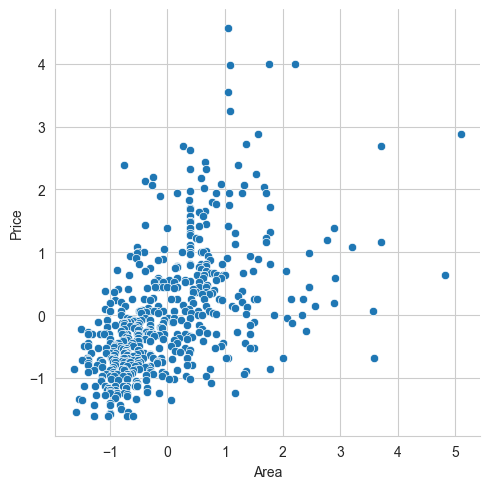

In [10]:
sns.relplot(
    data= Housing_data,
    x = "Area",
    y = "Price"
)

In [11]:
def pred_house_price(x, w, b):
    y_pred = w * x + b
    return y_pred

In [28]:
w = np.random.randint(1, 100)
b = np.random.randint(1, 100)
print(w, b)

46 37


In [29]:
Housing_data["Random_Pred_Price"] = pred_house_price(Housing_data["Area"],w, b)
Housing_data.head()

,Area,Price,Random_Pred_Price
0,1.045766,4.562174,85.105215
1,1.755397,4.000809,117.748255
2,2.216196,4.000809,138.945034
3,1.082630,3.982096,86.800958
4,1.045766,3.551716,85.105215


In [98]:
"""Cost function Calculation"""
def cost_function(x, y_true, w, b):
    y_pred = pred_house_price(y_true, w, b)
    MSE = np.mean((y_true - y_pred)**2) / 2
    return MSE
x = Housing_data["Area"]
y_true = Housing_data["Price"]
loss = cost_function(x, y_true, w, b)
print(loss)

0.044006912940232464


In [99]:
loss1 = cost_function(x, y_true, w = 40, b = 35)
print(loss1)
loss2 = cost_function(x, y_true, w = 35, b = 28)
print(loss2)
loss3 = cost_function(x, y_true, w = 30, b = 23)
print(loss3)

1371.604587155963
968.9394495412844
684.2284403669723


In [100]:
""" Gradient descent Algorithm"""
def compute_gradient(x, y_true, w, b):
    delta = 1e-9
    cost_1 = cost_function(x, y_true, w, b)
    cost_2 = cost_function(x, y_true, w + delta, b)
    cost_3 = cost_function(x, y_true, w, b + delta)
    dw = (cost_2 - cost_1) / delta
    db = (cost_3 - cost_1) / delta
    return dw, db


In [35]:
print(w, b)

46 37


In [36]:
loss = cost_function(x, y_true, w, b)
print(loss)

1716.4471604022924


In [40]:
dw, db = compute_gradient(x, y_true, w, b)
print(dw, db)

45.380602387012914 36.99960871017538


In [93]:
learning_rate = 0.001
w = w - learning_rate * dw
b = b - learning_rate * db


In [94]:
loss = cost_function(x, y_true, w, b)
print(loss)

1007.9638401033137


In [95]:
for epoch in range(5000):
    loss = cost_function(x, y_true, w, b)
    dw, db = compute_gradient(x, y_true, w, b)
    w = w - learning_rate * dw
    b = b - learning_rate * db

    if epoch % 1000 == 0:
        print(loss)


1007.9638401033137
136.88576839890666
18.855464298781982
2.8624178276175773
0.6953610205209468


In [96]:
print(w, b)

0.7723547421163026 0.19049028675740587


In [101]:
Housing_data["Learned_price"] = pred_house_price(Housing_data["Price"], w, b)
Housing_data.head()

,Area,Price,Random_Pred_Price,Learned_price
0,1.045766,4.562174,85.105215,3.714107
1,1.755397,4.000809,117.748255,3.280534
2,2.216196,4.000809,138.945034,3.280534
3,1.082630,3.982096,86.800958,3.266081
4,1.045766,3.551716,85.105215,2.933675
